# Exploratory Data Analysis (EDA)

Fase de análisis preliminar crucial y abierta en la que los científicos de datos inspeccionan los conjuntos de datos para comprender su estructura, detectar valores atípicos, verificar suposiciones y descubrir patrones iniciales.

In [ ]:
## Dependencias

In [1]:
from sklearn.datasets import load_wine
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np

## Problema
wine dataset (classification), para el set de datos https://scikit-learn.org/1.5/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine

## Data

In [2]:
data = load_wine(as_frame=True)
data = data.frame

In [3]:
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
data.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [5]:
data.keys()

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [6]:
# Número de datos por cada clase
data['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

## Data understanding 

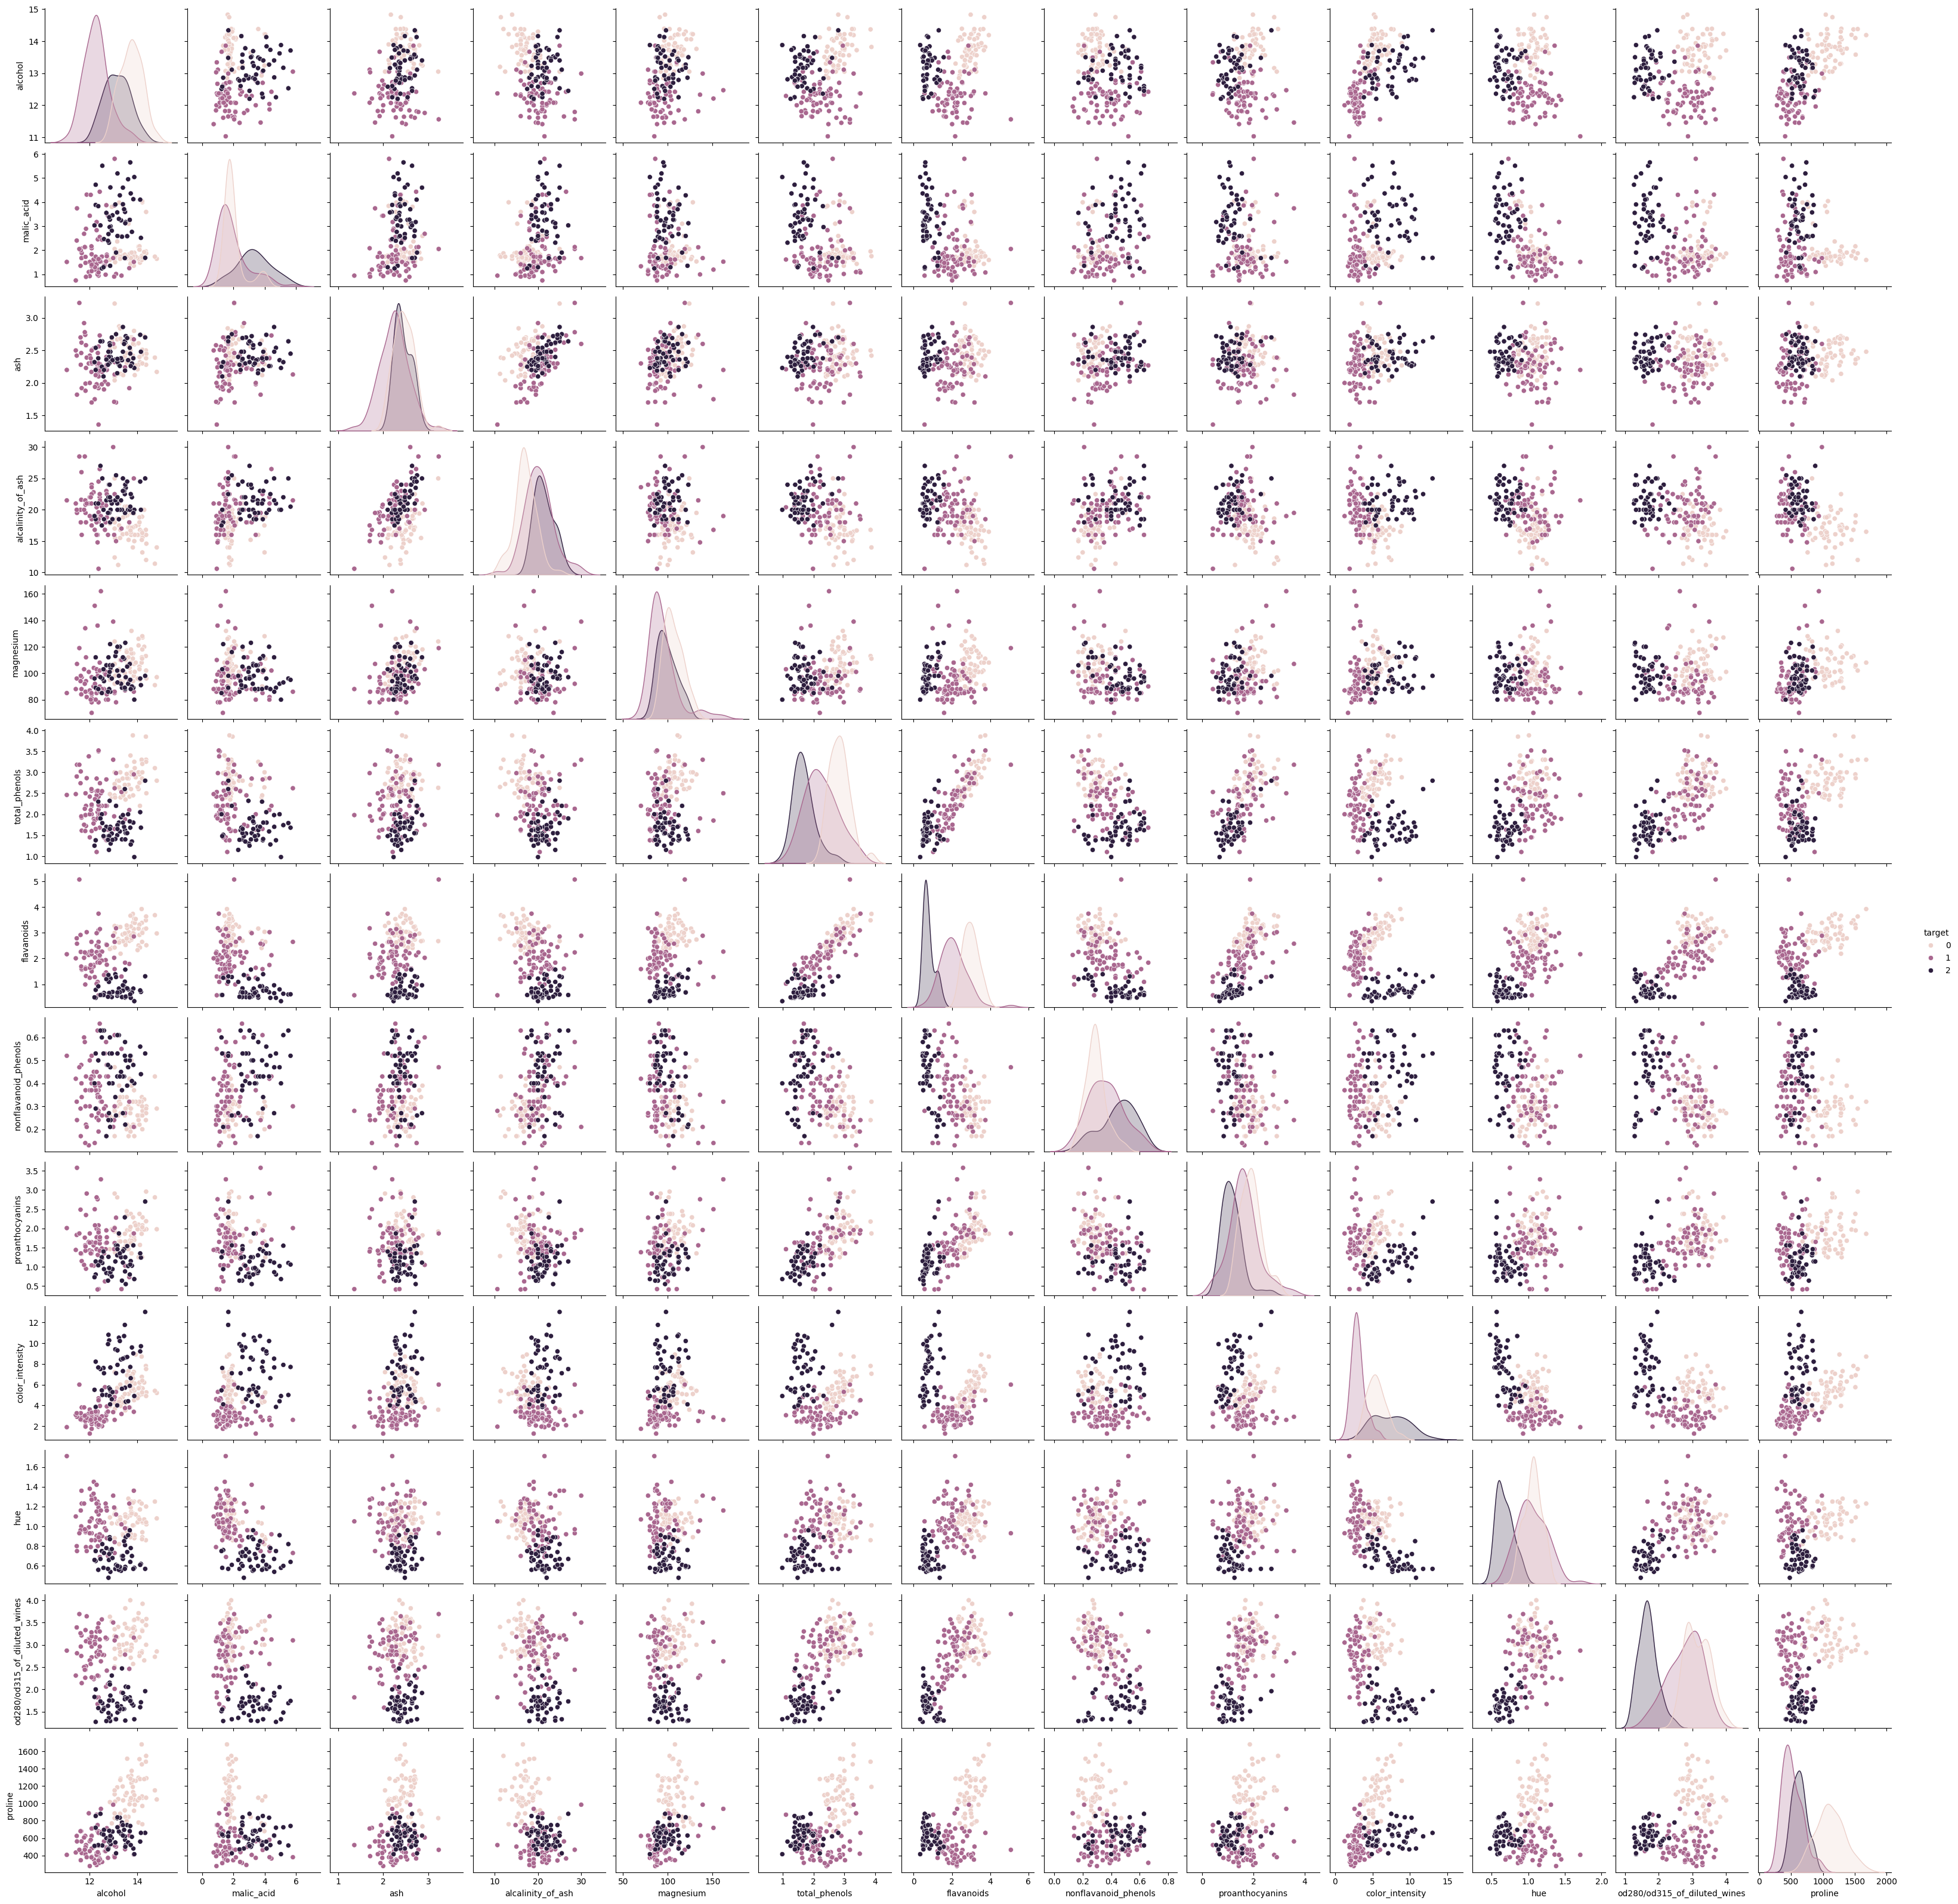

In [7]:
sns.pairplot(data=data, hue="target")

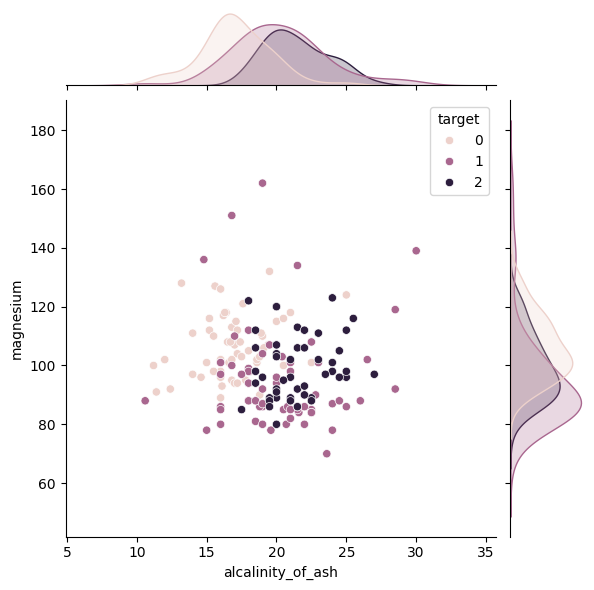

In [8]:
sns.jointplot(data=data, x="alcalinity_of_ash", y="magnesium", hue="target")

In [9]:
# Descripción estadistica
data.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


### Correlación

In [10]:
# Correlación Pearson
data.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


<Axes: xlabel='flavanoids', ylabel='total_phenols'>

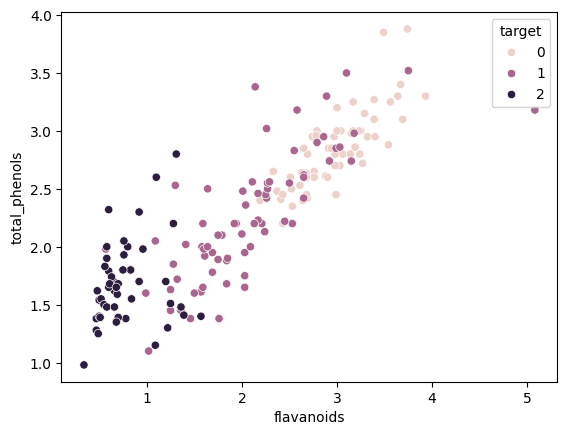

In [11]:
# Relación entre variables
sns.scatterplot(data=data, x='flavanoids', y='total_phenols', hue='target')

## Data preparation - modeling

In [12]:
target_value_1 = 1 
target_value_2 = 2 

In [13]:
data_filtered = data[(data['target']==target_value_1) | (data['target']==target_value_2)]

In [14]:
data_filtered = data_filtered[['alcalinity_of_ash', 'magnesium', 'target']].copy()
data_filtered.columns = ['feature_1', 'feature_2', 'target']
data_filtered['target']= data_filtered['target'].map({target_value_1: 0, target_value_2: 1})

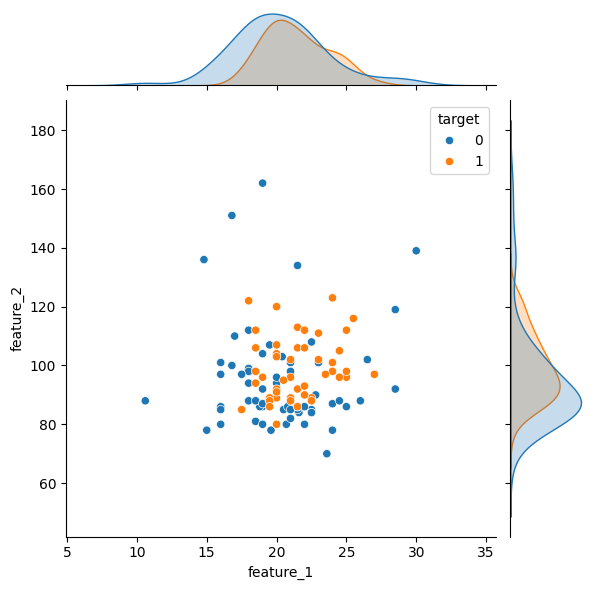

In [15]:
sns.jointplot(data=data_filtered, x="feature_1", y="feature_2", hue="target")

In [16]:
X = data_filtered[['feature_1', 'feature_2']]
y = data_filtered['target']

### Decision Trees

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from graphviz import Source
from sklearn.metrics import confusion_matrix, f1_score

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

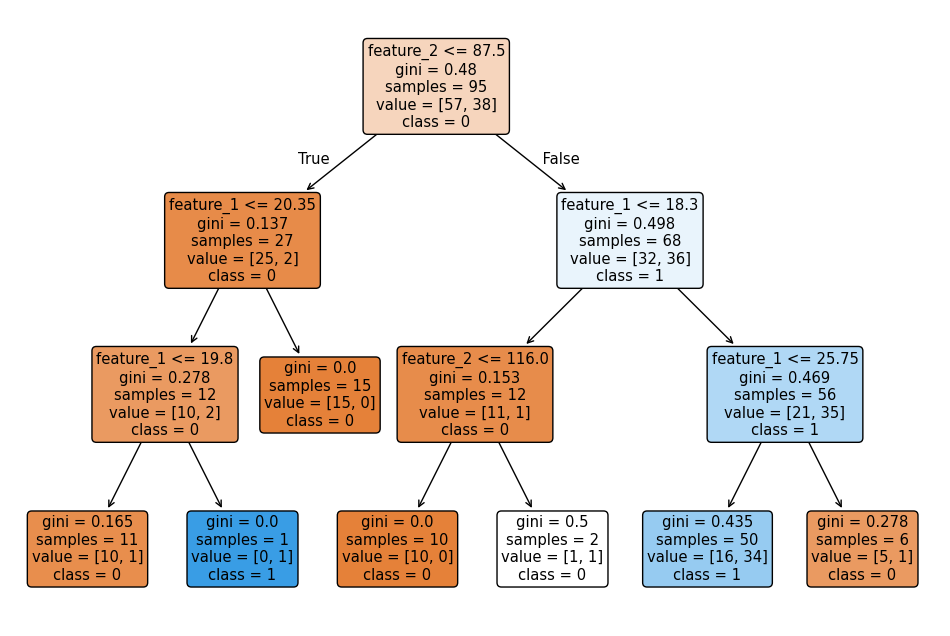

In [20]:
plt.figure(figsize=(12, 8))  # Ajusta el tamaño de la figura según sea necesario
plot_tree(
    tree_clf,
    feature_names=['feature_1', 'feature_2'],  # Nombres de las características
    class_names=list(map(str, data_filtered['target'].unique())),  # Nombres de las clases
    rounded=True,
    filled=True
)

plt.show()

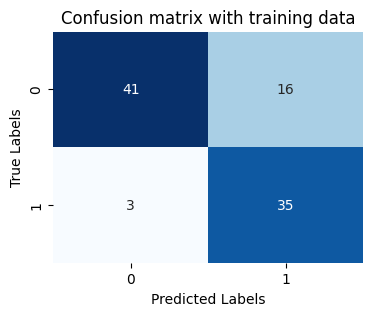

In [21]:
y_pred_train = tree_clf.predict(X_train)
conf_matrix = confusion_matrix(y_train, y_pred_train)

# Crear el gráfico de la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

# Añadir etiquetas y título
plt.title('Confusion matrix with training data')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Mostrar el gráfico
plt.show()

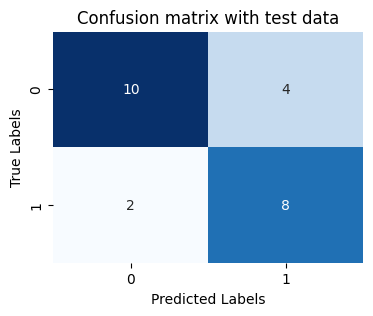

In [22]:
y_pred = tree_clf.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

# Crear el gráfico de la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

# Añadir etiquetas y título
plt.title('Confusion matrix with test data')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Mostrar el gráfico
plt.show()

In [23]:
f1_score(y_test, y_pred)

0.7272727272727273

### SVM

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.inspection import DecisionBoundaryDisplay

In [25]:
svm_clf = make_pipeline(StandardScaler(), SVC(kernel='rbf')) # 'linear', 'poly', 'rbf', 'sigmoid'
# Entrenar el clasificador
svm_clf.fit(X_train, y_train)

# Hacer predicciones
y_pred = svm_clf.predict(X_test)

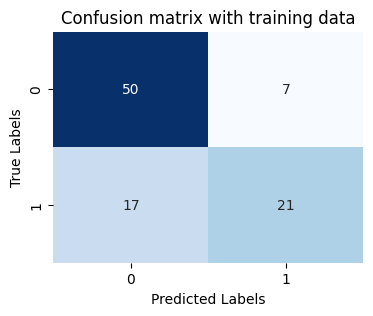

In [26]:
y_pred_train = svm_clf.predict(X_train)
conf_matrix = confusion_matrix(y_train, y_pred_train)

# Crear el gráfico de la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

# Añadir etiquetas y título
plt.title('Confusion matrix with training data')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Mostrar el gráfico
plt.show()

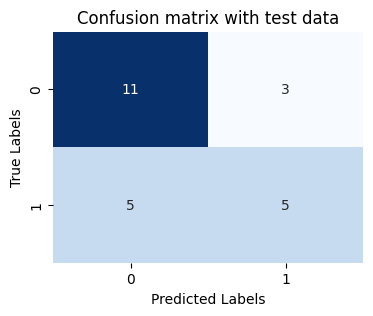

In [27]:
y_pred = svm_clf.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

# Crear el gráfico de la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

# Añadir etiquetas y título
plt.title('Confusion matrix with test data')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Mostrar el gráfico
plt.show()

In [28]:
f1_score(y_test, y_pred)

0.5555555555555556

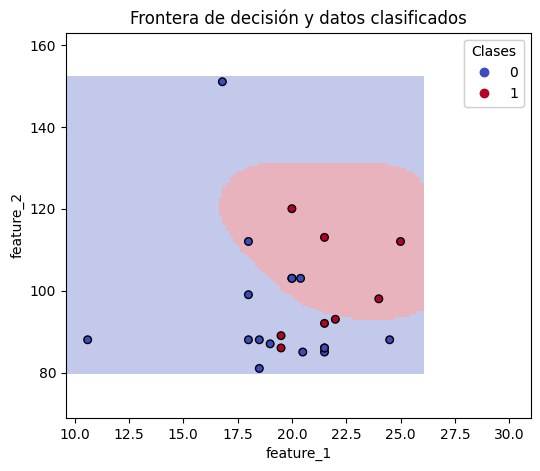

In [29]:
# Gráfico de la frontera de decisión
_, ax = plt.subplots(figsize=(6, 5))
x_min, x_max = X['feature_1'].min() - 1, X['feature_1'].max() + 1
y_min, y_max = X['feature_2'].min() - 1, X['feature_2'].max() + 1
ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

# Usar la misma paleta de colores para la frontera de decisión y los puntos
cmap = plt.cm.coolwarm

# Mostrar la frontera de decisión
DecisionBoundaryDisplay.from_estimator(
    estimator=svm_clf,
    X=X_test,
    ax=ax,
    response_method="predict",
    plot_method="pcolormesh",
    cmap=cmap,  # Usar la misma paleta de colores
    alpha=0.3,
)

# Graficar los puntos de las clases usando iloc para seleccionar las columnas por índice
scatter = ax.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test, cmap=cmap, s=30, edgecolors='k')

# Añadir una leyenda para las clases
legend = ax.legend(*scatter.legend_elements(), title="Clases")
ax.add_artist(legend)

# Título y etiquetas
ax.set_title('Frontera de decisión y datos clasificados')
ax.set_xlabel('feature_1')
ax.set_ylabel('feature_2')

# Mostrar el gráfico
plt.show()

### No supervisados

In [30]:
target_value_1 = 1 
target_value_2 = 2 
data_filtered = data[(data['target']==target_value_1) | (data['target']==target_value_2)]
data_filtered = data_filtered[['flavanoids', 'color_intensity', 'target']].copy()
data_filtered.columns = ['feature_1', 'feature_2', 'target']
data_filtered['target']= data_filtered['target'].map({target_value_1: 0, target_value_2: 1})

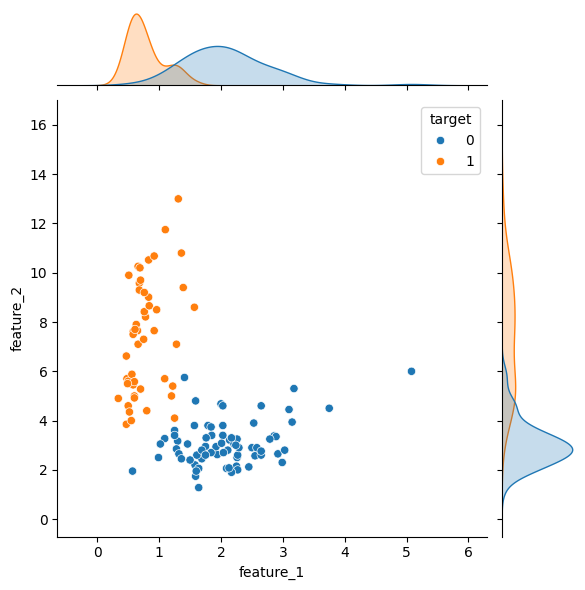

In [31]:
sns.jointplot(data=data_filtered, x="feature_1", y="feature_2", hue="target")

In [32]:
X = data_filtered[['feature_1', 'feature_2']]
#y = data_filtered['target']

#### Kmeans

In [33]:
from sklearn.cluster import KMeans

##### Sin escalar

In [34]:
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)

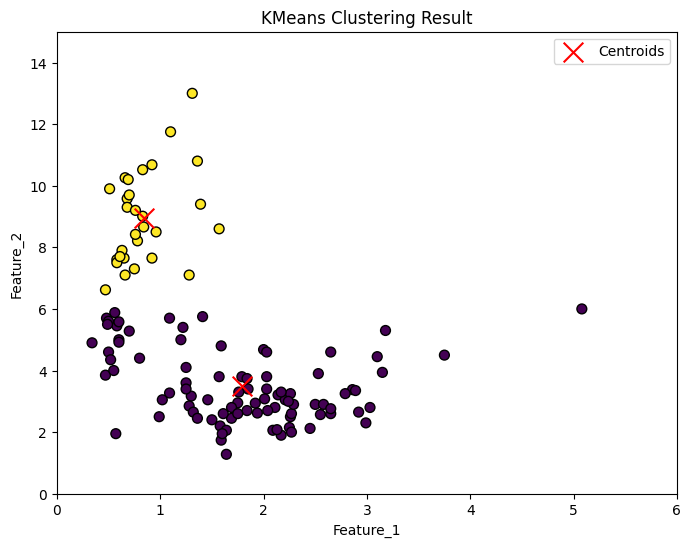

In [35]:
# Obtener las etiquetas de los clústeres
labels = kmeans.labels_

# Obtener los centros de los clústeres
centroids = kmeans.cluster_centers_

# Graficar los puntos de datos
plt.figure(figsize=(8, 6))

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k', s=50)

# Graficar los centros de los clústeres
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, label='Centroids')

plt.xlim(0, 6)
plt.ylim(0, 15)

# Añadir título y etiquetas
plt.title('KMeans Clustering Result')
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.legend()

# Mostrar el gráfico
plt.show()

##### Escalado

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
kmeans_scaled = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X_scaled)

/var/folders/kg/plkd97154_zf916xg8gj219h0000gn/T/ipykernel_82417/2351976742.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


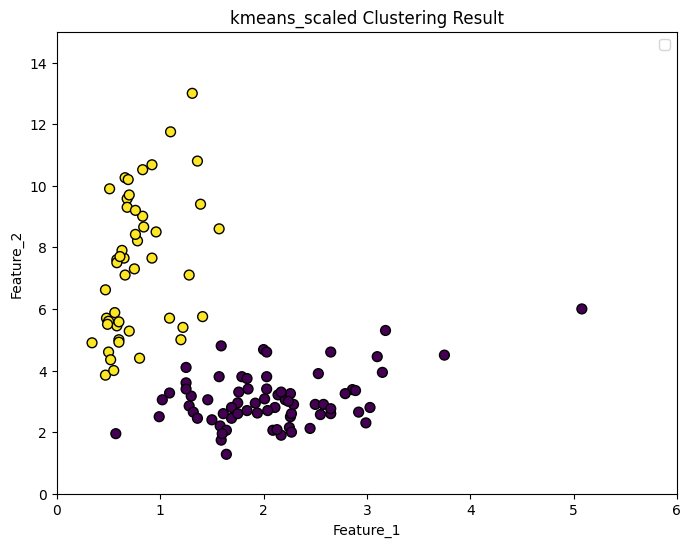

In [38]:
# Obtener las etiquetas de los clústeres
labels = kmeans_scaled.labels_

# Obtener los centros de los clústeres
centroids = kmeans_scaled.cluster_centers_

# Graficar los puntos de datos
plt.figure(figsize=(8, 6))

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k', s=50)

# Graficar los centros de los clústeres
#plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, label='Centroids')
plt.xlim(0, 6)
plt.ylim(0, 15)
# Añadir título y etiquetas
plt.title('kmeans_scaled Clustering Result')
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.legend()

# Mostrar el gráfico
plt.show()

#### DBSCAN

In [39]:
from sklearn.cluster import DBSCAN

In [40]:
# Ajustar el modelo DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=5).fit(X)

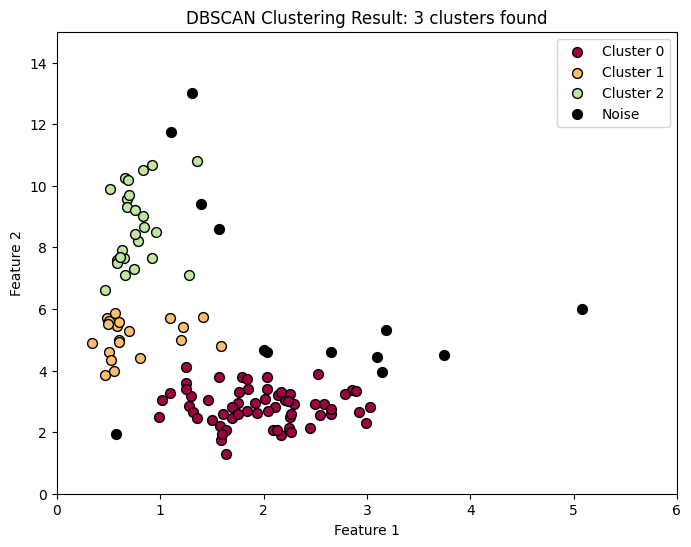

In [41]:
# Obtener las etiquetas de los clústeres
labels = dbscan.labels_

# Número de clústeres (excluyendo el ruido si existe)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Graficar los puntos de datos
plt.figure(figsize=(8, 6))

# Colorear los puntos por clúster, con -1 para el ruido
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Color para el ruido (puntos no clasificados)
        col = [0, 0, 0, 1]  # Negro

    class_member_mask = (labels == k)

    xy = X[class_member_mask]
    plt.scatter(xy.iloc[:, 0], xy.iloc[:, 1], s=50, color=tuple(col), edgecolor='k', label=f'Cluster {k}' if k != -1 else 'Noise')

plt.xlim(0, 6)
plt.ylim(0, 15)

# Añadir título y etiquetas
plt.title(f'DBSCAN Clustering Result: {n_clusters} clusters found')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()


# Mostrar el gráfico
plt.show()

##### Scaled

In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [43]:
# Ajustar el modelo DBSCAN
dbscan_scaled = DBSCAN(eps=0.4, min_samples=4).fit(X_scaled)

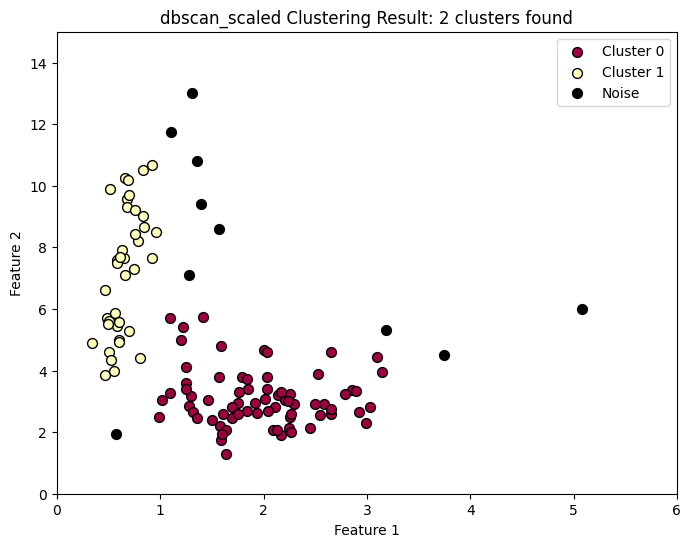

In [44]:
# Obtener las etiquetas de los clústeres
labels = dbscan_scaled.labels_

# Número de clústeres (excluyendo el ruido si existe)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Graficar los puntos de datos
plt.figure(figsize=(8, 6))

# Colorear los puntos por clúster, con -1 para el ruido
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Color para el ruido (puntos no clasificados)
        col = [0, 0, 0, 1]  # Negro

    class_member_mask = (labels == k)

    xy = X[class_member_mask]
    plt.scatter(xy.iloc[:, 0], xy.iloc[:, 1], s=50, color=tuple(col), edgecolor='k', label=f'Cluster {k}' if k != -1 else 'Noise')

plt.xlim(0, 6)
plt.ylim(0, 15)

# Añadir título y etiquetas
plt.title(f'dbscan_scaled Clustering Result: {n_clusters} clusters found')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Mostrar el gráfico
plt.show()